# IPL Analysis 

In [6]:
# Setup — imports and data load
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\DA SpeedUP\PORTFOLIO PROJECT\archive\deliveries.csv")
matches = pd.read_csv(r"D:\DA SpeedUP\PORTFOLIO PROJECT\archive\matches.csv")

# Team name cleaning
team_name_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
}
df["batting_team"] = df["batting_team"].replace(team_name_map)
df["bowling_team"] = df["bowling_team"].replace(team_name_map)

for col in ["team1", "team2", "toss_winner", "winner"]:
    matches[col] = matches[col].replace(team_name_map)

## 1. Batting Analysis

In [7]:
# 1.1 Batting average & strike rate per player
balls_faced = df.groupby("batter")["batter"].count()
runs_scored = df.groupby("batter")["batsman_runs"].sum()
dismissals = df[df["player_dismissed"] == df["player_dismissed"]].groupby("player_dismissed")["player_dismissed"].count()
# safer: count dismissals using player_dismissed column directly
dismissals = df["player_dismissed"].value_counts()

batting_stats = pd.DataFrame({
    "runs": runs_scored,
    "balls_faced": balls_faced,
    "dismissals": dismissals
}).fillna(0)

batting_stats["average"] = batting_stats["runs"] / batting_stats["dismissals"].replace(0, pd.NA)
batting_stats["strike_rate"] = (batting_stats["runs"] / batting_stats["balls_faced"]) * 100

# filter to players with a meaningful sample size
qualified = batting_stats[batting_stats["balls_faced"] > 500]
print("Top averages:")
print(qualified.sort_values("average", ascending=False).head(10))
print()
print("Top strike rates:")
print(qualified.sort_values("strike_rate", ascending=False).head(10))


Top averages:
                   runs  balls_faced  dismissals    average  strike_rate
DP Conway         924.0        669.0        19.0  48.631579   138.116592
B Sai Sudharsan  1034.0        770.0        22.0       47.0   134.285714
KL Rahul         4689.0       3578.0       105.0  44.657143   131.050866
RD Gaikwad       2380.0       1781.0        57.0  41.754386   133.632791
DA Warner        6567.0       4849.0       164.0  40.042683   135.429986
LMP Simmons      1079.0        878.0        27.0  39.962963   122.892938
Tilak Varma      1156.0        830.0        29.0  39.862069   139.277108
AB de Villiers   5181.0       3487.0       130.0  39.853846   148.580442
JP Duminy        2029.0       1680.0        51.0  39.784314   120.773810
CH Gayle         4997.0       3516.0       126.0   39.65873   142.121729

Top strike rates:
                   runs  balls_faced  dismissals    average  strike_rate
AD Russell       2488.0       1515.0        86.0  28.930233   164.224422
H Klaasen         

In [8]:
# 1.2 Most fours vs most sixes
fours = df[df["batsman_runs"] == 4].groupby("batter")["batsman_runs"].count().sort_values(ascending=False)
sixes = df[df["batsman_runs"] == 6].groupby("batter")["batsman_runs"].count().sort_values(ascending=False)

print("Most fours:")
print(fours.head(10))
print()
print("Most sixes:")
print(sixes.head(10))


Most fours:
batter
S Dhawan        768
V Kohli         708
DA Warner       663
RG Sharma       599
SK Raina        506
G Gambhir       492
RV Uthappa      481
AM Rahane       479
KD Karthik      466
F du Plessis    422
Name: batsman_runs, dtype: int64

Most sixes:
batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
Name: batsman_runs, dtype: int64


In [9]:
# 1.3 Best strike rate: powerplay (overs 0-5) vs death overs (16-19)
powerplay = df[df["over"] < 6]
death = df[df["over"] >= 16]

def strike_rate_by_phase(phase_df, min_balls=200):
    runs = phase_df.groupby("batter")["batsman_runs"].sum()
    balls = phase_df.groupby("batter")["batter"].count()
    sr = (runs / balls * 100)
    return sr[balls > min_balls].sort_values(ascending=False)

print("Best powerplay strike rate:")
print(strike_rate_by_phase(powerplay).head(10))
print()
print("Best death-over strike rate:")
print(strike_rate_by_phase(death, min_balls=100).head(10))


Best powerplay strike rate:
batter
TM Head            195.260664
PD Salt            166.942149
SP Narine          163.951473
Abhishek Sharma    151.297405
YBK Jaiswal        149.039882
JM Bairstow        142.574257
P Simran Singh     142.571429
PP Shaw            142.389006
YK Pathan          141.015625
E Lewis            140.939597
dtype: float64

Best death-over strike rate:
batter
AB de Villiers    223.779528
LS Livingstone    198.058252
RR Pant           196.855346
CH Gayle          193.301435
V Kohli           192.469352
JH Kallis         190.566038
H Klaasen         190.062112
F du Plessis      189.090909
RG Sharma         188.160000
SA Yadav          186.956522
dtype: float64


In [10]:
# 1.4 Count of 50s and 100s per batter
# Requires runs per player per match first
runs_per_match = df.groupby(["match_id", "batter"])["batsman_runs"].sum().reset_index()

fifties = runs_per_match[(runs_per_match["batsman_runs"] >= 50) & (runs_per_match["batsman_runs"] < 100)]
hundreds = runs_per_match[runs_per_match["batsman_runs"] >= 100]

print("Most 50s:")
print(fifties.groupby("batter")["batsman_runs"].count().sort_values(ascending=False).head(10))
print()
print("Most 100s:")
print(hundreds.groupby("batter")["batsman_runs"].count().sort_values(ascending=False).head(10))


Most 50s:
batter
DA Warner         62
V Kohli           56
S Dhawan          51
RG Sharma         43
AB de Villiers    41
SK Raina          39
KL Rahul          37
F du Plessis      37
G Gambhir         36
CH Gayle          32
Name: batsman_runs, dtype: int64

Most 100s:
batter
V Kohli           8
JC Buttler        7
CH Gayle          6
SR Watson         4
KL Rahul          4
DA Warner         4
Shubman Gill      4
AB de Villiers    3
SV Samson         3
HM Amla           2
Name: batsman_runs, dtype: int64


In [11]:
# 1.5 Boundary percentage per batter (runs from 4s & 6s / total runs)
boundary_runs = df[df["batsman_runs"].isin([4, 6])].groupby("batter")["batsman_runs"].sum()
total_runs_batter = df.groupby("batter")["batsman_runs"].sum()

boundary_pct = (boundary_runs / total_runs_batter * 100).fillna(0)
boundary_pct = boundary_pct[total_runs_batter > 500]  # filter low-sample players
print(boundary_pct.sort_values(ascending=False).head(10))


batter
SP Narine         80.704042
AD Russell        77.893891
PD Salt           76.569678
CH Gayle          75.765459
ST Jayasuriya     74.218750
P Simran Singh    73.809524
YBK Jaiswal       73.428749
AC Gilchrist      72.885452
V Sehwag          72.287390
PC Valthaty       72.079208
Name: batsman_runs, dtype: float64


## 2. Bowling Analysis

In [12]:
# 2.1 Economy rate per bowler (runs conceded per over)
# overs bowled = balls bowled / 6 (approx, ignoring wide/noball technicalities)
balls_bowled = df.groupby("bowler")["bowler"].count()
runs_conceded = df.groupby("bowler")["total_runs"].sum()

economy = (runs_conceded / (balls_bowled / 6))
economy = economy[balls_bowled > 300]  # filter for meaningful sample
print("Best economy (min 300 balls bowled):")
print(economy.sort_values().head(10))


Best economy (min 300 balls bowled):
bowler
A Kumble            6.646999
GD McGrath          6.674772
M Muralitharan      6.698292
J Yadav             6.738693
SP Narine           6.761216
RE van der Merwe    6.791209
DW Steyn            6.791411
DL Vettori          6.833121
Rashid Khan         6.907963
J Botha             6.922426
dtype: float64


In [13]:
# 2.2 Best bowling figures in a single match (most wickets, fewest runs as tiebreak)
match_bowling = df.groupby(["match_id", "bowler"]).agg(
    wickets=("is_wicket", "sum"),
    runs=("total_runs", "sum")
).reset_index()

best_figures = match_bowling.sort_values(["wickets", "runs"], ascending=[False, True]).head(10)
print(best_figures)


       match_id         bowler  wickets  runs
12086   1370351  Akash Madhwal        6     6
8499    1178394      AS Joseph        6    14
290      336005  Sohail Tanvir        6    15
6609     980979        A Zampa        6    19
4546     598056      DJG Sammy        6    23
6510     980963     AD Russell        6    25
9668    1254058       HV Patel        6    27
11969   1359536        B Kumar        6    31
696      392182       A Kumble        5     6
1506     419115       A Kumble        5    10


In [14]:
# 2.3 Bowler vs specific batter head-to-head
def head_to_head(batter_name, bowler_name):
    matchup = df[(df["batter"] == batter_name) & (df["bowler"] == bowler_name)]
    runs = matchup["batsman_runs"].sum()
    balls = len(matchup)
    dismissals = matchup["is_wicket"].sum()
    print(f"{batter_name} vs {bowler_name}: {runs} runs off {balls} balls, dismissed {dismissals} times")

# Example usage — change names as needed
head_to_head("V Kohli", "JJ Bumrah")


V Kohli vs JJ Bumrah: 145 runs off 98 balls, dismissed 5 times


In [15]:
# 2.4 Dot ball percentage per bowler (pressure-building ability)
dot_balls = df[df["batsman_runs"] == 0].groupby("bowler")["bowler"].count()
total_balls = df.groupby("bowler")["bowler"].count()

dot_pct = (dot_balls / total_balls * 100)
dot_pct = dot_pct[total_balls > 300]
print(dot_pct.sort_values(ascending=False).head(10))


bowler
SW Tait          52.621723
BW Hilfenhaus    51.282051
DW Steyn         50.788782
GD McGrath       50.455927
DP Nannes        50.362845
S Sreesanth      49.736008
IC Pandey        48.827292
RJ Harris        48.786127
DE Bollinger     48.666667
JC Archer        48.632219
Name: bowler, dtype: float64


In [16]:
# 2.5 Best powerplay bowlers vs best death-over bowlers (by wickets)
powerplay_wickets = powerplay.groupby("bowler")["is_wicket"].sum().sort_values(ascending=False)
death_wickets = death.groupby("bowler")["is_wicket"].sum().sort_values(ascending=False)

print("Top powerplay wicket-takers:")
print(powerplay_wickets.head(10))
print()
print("Top death-over wicket-takers:")
print(death_wickets.head(10))


Top powerplay wicket-takers:
bowler
B Kumar           77
TA Boult          63
Sandeep Sharma    63
UT Yadav          61
DL Chahar         60
I Sharma          60
Z Khan            58
R Ashwin          53
Mohammed Shami    51
DS Kulkarni       46
Name: is_wicket, dtype: int64

Top death-over wicket-takers:
bowler
DJ Bravo          115
SL Malinga        104
B Kumar            93
JJ Bumrah          89
HV Patel           74
MM Sharma          72
SP Narine          69
Mohammed Shami     69
CH Morris          61
R Vinay Kumar      58
Name: is_wicket, dtype: int64


## 3. Team-Level Analysis (matches.csv)

In [18]:
# 3.1 Team win percentage overall
team_matches = pd.concat([matches["team1"], matches["team2"]]).value_counts()
team_wins = matches["winner"].value_counts()

win_pct = (team_wins / team_matches * 100).dropna().sort_values(ascending=False)
print(win_pct)


Gujarat Titans                 62.222222
Chennai Super Kings            57.983193
Mumbai Indians                 55.172414
Lucknow Super Giants           54.545455
Kolkata Knight Riders          52.191235
Rajasthan Royals               50.678733
Rising Pune Supergiants        50.000000
Sunrisers Hyderabad            48.351648
Royal Challengers Bengaluru    48.235294
Kings XI Punjab                46.315789
Delhi Capitals                 45.634921
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Punjab Kings                   42.857143
Deccan Chargers                38.666667
Pune Warriors                  26.086957
Name: count, dtype: float64


In [19]:
# 3.2 Toss decision impact — does winning toss correlate with winning match?
matches["toss_win_match_win"] = matches["toss_winner"] == matches["winner"]
print(matches["toss_win_match_win"].value_counts(normalize=True) * 100)

print()
print("By toss decision:")
print(matches.groupby("toss_decision")["toss_win_match_win"].mean() * 100)


toss_win_match_win
True     50.593607
False    49.406393
Name: proportion, dtype: float64

By toss decision:
toss_decision
bat      45.268542
field    53.551136
Name: toss_win_match_win, dtype: float64


In [20]:
# 3.3 Team performance by season (wins per season)
wins_by_season = matches.groupby(["season", "winner"])["winner"].count().reset_index(name="wins")
# example: filter to one team's trend over the years
one_team = wins_by_season[wins_by_season["winner"] == "Chennai Super Kings"]
print(one_team)


      season               winner  wins
0    2007/08  Chennai Super Kings     9
8       2009  Chennai Super Kings     8
16   2009/10  Chennai Super Kings     9
24      2011  Chennai Super Kings    11
34      2012  Chennai Super Kings    10
43      2013  Chennai Super Kings    12
52      2014  Chennai Super Kings    10
60      2015  Chennai Super Kings    10
84      2018  Chennai Super Kings    11
92      2019  Chennai Super Kings    10
100  2020/21  Chennai Super Kings     6
108     2021  Chennai Super Kings    11
116     2022  Chennai Super Kings     4
126     2023  Chennai Super Kings    10
136     2024  Chennai Super Kings     7


In [21]:
# 3.4 Highest team totals & biggest win margins
team_totals = df.groupby(["match_id", "batting_team"])["total_runs"].sum().reset_index()
print("Highest team totals:")
print(team_totals.sort_values("total_runs", ascending=False).head(10))

print()
print("Biggest win margins (by runs):")
runs_wins = matches[matches["result"] == "runs"]
print(runs_wins.sort_values("result_margin", ascending=False)[["season", "team1", "team2", "winner", "result_margin"]].head(10))


Highest team totals:
      match_id                 batting_team  total_runs
2104   1426268          Sunrisers Hyderabad         287
2060   1422126          Sunrisers Hyderabad         277
2076   1422134        Kolkata Knight Riders         272
2114   1426273          Sunrisers Hyderabad         266
702     598027  Royal Challengers Bengaluru         263
2128   1426280                 Punjab Kings         262
2103   1426268  Royal Challengers Bengaluru         262
2127   1426280        Kolkata Knight Riders         261
2129   1426281               Delhi Capitals         257
1972   1359512         Lucknow Super Giants         257

Biggest win margins (by runs):
       season                        team1                        team2  \
620      2017               Delhi Capitals               Mumbai Indians   
560      2016  Royal Challengers Bengaluru                Gujarat Lions   
0     2007/08  Royal Challengers Bengaluru        Kolkata Knight Riders   
496      2015  Royal Challenger

In [22]:
# 3.5 Head-to-head record between two chosen teams
def head_to_head_teams(team_a, team_b):
    h2h = matches[
        ((matches["team1"] == team_a) & (matches["team2"] == team_b)) |
        ((matches["team1"] == team_b) & (matches["team2"] == team_a))
    ]
    print(f"Total matches: {len(h2h)}")
    print(h2h["winner"].value_counts())

# Example usage
head_to_head_teams("Mumbai Indians", "Chennai Super Kings")


Total matches: 37
winner
Mumbai Indians         20
Chennai Super Kings    17
Name: count, dtype: int64


## 4. Match-Context Analysis

In [23]:
# 4.1 Most frequent Player of the Match winners
print(matches["player_of_match"].value_counts().head(10))


player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
AD Russell        15
Name: count, dtype: int64


In [24]:
# 4.2 Super over matches — frequency and winners
super_overs = matches[matches["super_over"] == "Y"]
print(f"Total super over matches: {len(super_overs)}")
print(super_overs["winner"].value_counts())


Total super over matches: 14
winner
Kings XI Punjab                3
Delhi Capitals                 3
Rajasthan Royals               2
Royal Challengers Bengaluru    2
Mumbai Indians                 2
Sunrisers Hyderabad            1
Kolkata Knight Riders          1
Name: count, dtype: int64


In [25]:
# 4.3 Venue analysis — highest/lowest scoring grounds
match_totals = df.groupby("match_id")["total_runs"].sum().reset_index()
match_totals = match_totals.merge(matches[["id", "venue"]], left_on="match_id", right_on="id")

venue_avg = match_totals.groupby("venue")["total_runs"].mean().sort_values(ascending=False)
print("Highest scoring venues (avg total runs per match, both innings):")
print(venue_avg.head(10))
print()
print("Lowest scoring venues:")
print(venue_avg.tail(10))


Highest scoring venues (avg total runs per match, both innings):
venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    400.000000
Arun Jaitley Stadium, Delhi                                           380.687500
Eden Gardens, Kolkata                                                 380.312500
M Chinnaswamy Stadium, Bengaluru                                      380.142857
Himachal Pradesh Cricket Association Stadium, Dharamsala              378.750000
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      371.200000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  364.846154
Brabourne Stadium                                                     348.100000
Punjab Cricket Association IS Bindra Stadium                          347.600000
Wankhede Stadium, Mumbai                                              346.377778
Name: total_runs, dtype: float64

Lowest scoring venues:
venue
Shaheed Veer Narayan Singh International Stadium       2

In [26]:
# 4.4 Season trends — average runs per match over the years
match_totals_season = match_totals.merge(matches[["id", "season"]], left_on="match_id", right_on="id", suffixes=("", "_dup"))
season_avg = match_totals_season.groupby("season")["total_runs"].mean()
print(season_avg)


season
2007/08    309.258621
2009       286.894737
2009/10    314.716667
2011       289.780822
2012       303.418919
2013       297.394737
2014       315.516667
2015       311.067797
2016       314.366667
2017       318.406780
2018       331.683333
2019       323.900000
2020/21    323.600000
2021       310.616667
2022       329.662162
2023       347.135135
2024       365.788732
Name: total_runs, dtype: float64


## 5. Cross-Dataset Analysis (merged deliveries + matches)

In [27]:
# 5.1 Merge deliveries with match context (season, venue, winner)
merged = df.merge(
    matches[["id", "season", "venue", "toss_winner", "toss_decision", "winner"]],
    left_on="match_id", right_on="id", how="left"
)
print(merged[["match_id", "batter", "batsman_runs", "season", "venue", "winner"]].head())


   match_id       batter  batsman_runs   season                  venue  \
0    335982   SC Ganguly             0  2007/08  M Chinnaswamy Stadium   
1    335982  BB McCullum             0  2007/08  M Chinnaswamy Stadium   
2    335982  BB McCullum             0  2007/08  M Chinnaswamy Stadium   
3    335982  BB McCullum             0  2007/08  M Chinnaswamy Stadium   
4    335982  BB McCullum             0  2007/08  M Chinnaswamy Stadium   

                  winner  
0  Kolkata Knight Riders  
1  Kolkata Knight Riders  
2  Kolkata Knight Riders  
3  Kolkata Knight Riders  
4  Kolkata Knight Riders  


season
2007/08    165
2009       246
2009/10    307
2011       557
2012       364
2013       639
2014       359
2015       505
2016       973
2017       308
2018       530
2019       464
2020/21    471
2021       405
2022       341
2023       639
2024       741
Name: batsman_runs, dtype: int64


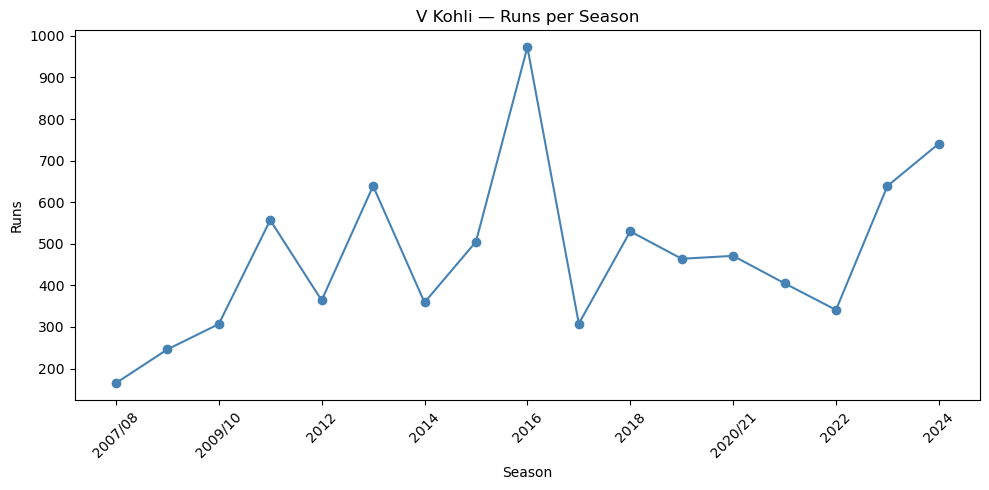

In [28]:
# 5.2 Player performance trend across seasons (example: V Kohli)
player_season_runs = merged[merged["batter"] == "V Kohli"].groupby("season")["batsman_runs"].sum()
print(player_season_runs)

plt.figure(figsize=(10,5))
player_season_runs.plot(kind="line", marker="o", color="steelblue")
plt.title("V Kohli — Runs per Season")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [29]:
# 5.3 Win rate when winning toss AND choosing to bat first, by venue
bat_first_toss_wins = matches[(matches["toss_winner"] == matches["winner"]) & (matches["toss_decision"] == "bat")]
venue_bat_first_win_rate = bat_first_toss_wins.groupby("venue")["winner"].count().sort_values(ascending=False)
print(venue_bat_first_win_rate.head(10))


venue
MA Chidambaram Stadium, Chepauk              21
Feroz Shah Kotla                             12
Eden Gardens                                 12
Wankhede Stadium                             11
Subrata Roy Sahara Stadium                    9
Dubai International Cricket Stadium           7
Sheikh Zayed Stadium                          7
Kingsmead                                     6
Sawai Mansingh Stadium                        6
Rajiv Gandhi International Stadium, Uppal     5
Name: winner, dtype: int64


In [30]:
# 5.4 Chasing vs defending — overall win rate when batting second
# In result="wickets", the team batting second (chasing) won
# In result="runs", the team batting first won
chase_wins = (matches["result"] == "wickets").sum()
defend_wins = (matches["result"] == "runs").sum()
total_decided = chase_wins + defend_wins

print(f"Chasing win %: {chase_wins/total_decided*100:.2f}")
print(f"Defending win %: {defend_wins/total_decided*100:.2f}")


Chasing win %: 53.72
Defending win %: 46.28


## 6. Additional Visualizations

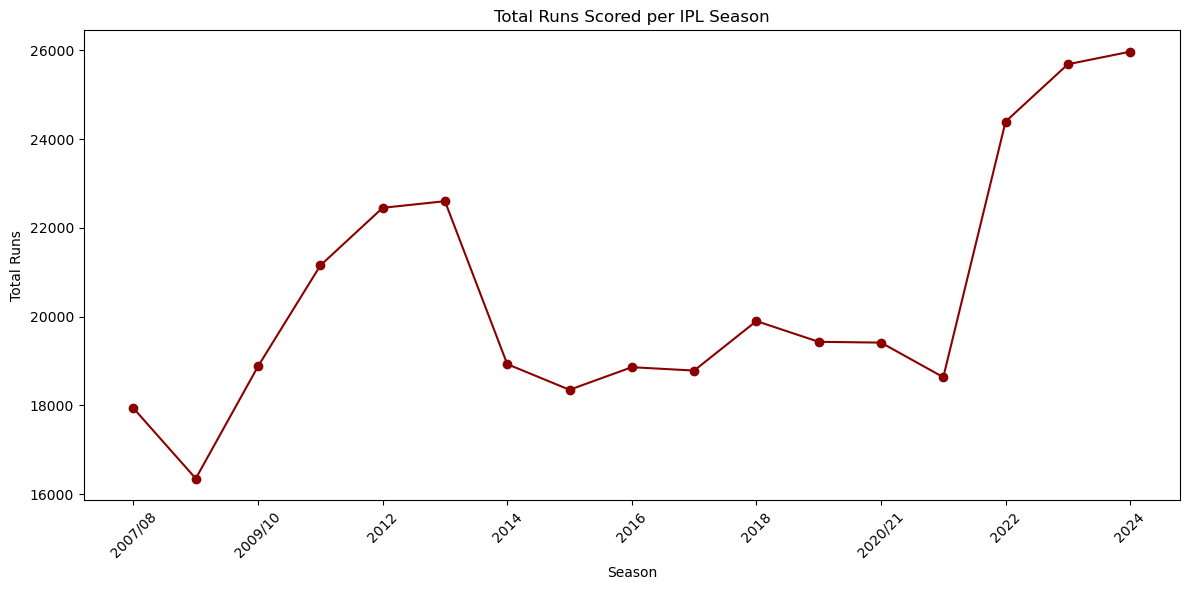

In [31]:
# 6.1 Total runs scored per season (batting trend over years)
runs_per_season = merged.groupby("season")["total_runs"].sum()

plt.figure(figsize=(12,6))
runs_per_season.plot(kind="line", marker="o", color="darkred")
plt.title("Total Runs Scored per IPL Season")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


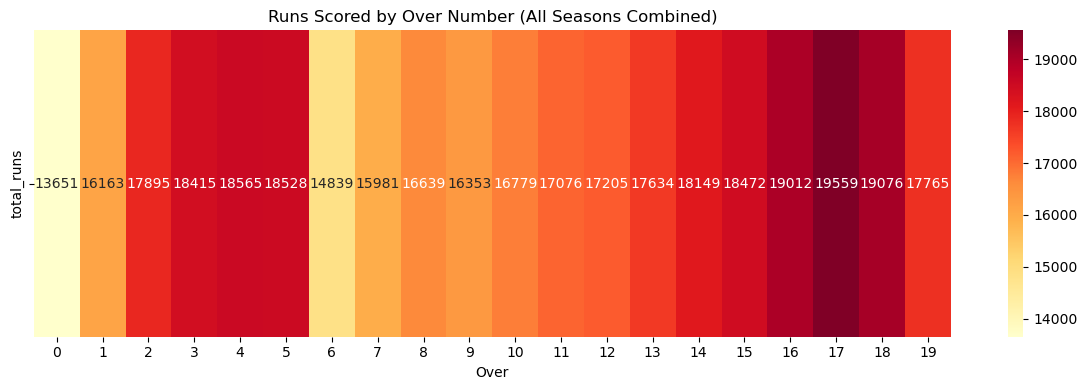

In [32]:
# 6.2 Heatmap — runs scored by over number (phase-wise scoring pattern)
over_runs = df.groupby("over")["total_runs"].sum().reset_index()

plt.figure(figsize=(12,4))
sns.heatmap(over_runs.set_index("over").T, cmap="YlOrRd", annot=True, fmt="g", cbar=True)
plt.title("Runs Scored by Over Number (All Seasons Combined)")
plt.xlabel("Over")
plt.tight_layout()
plt.show()


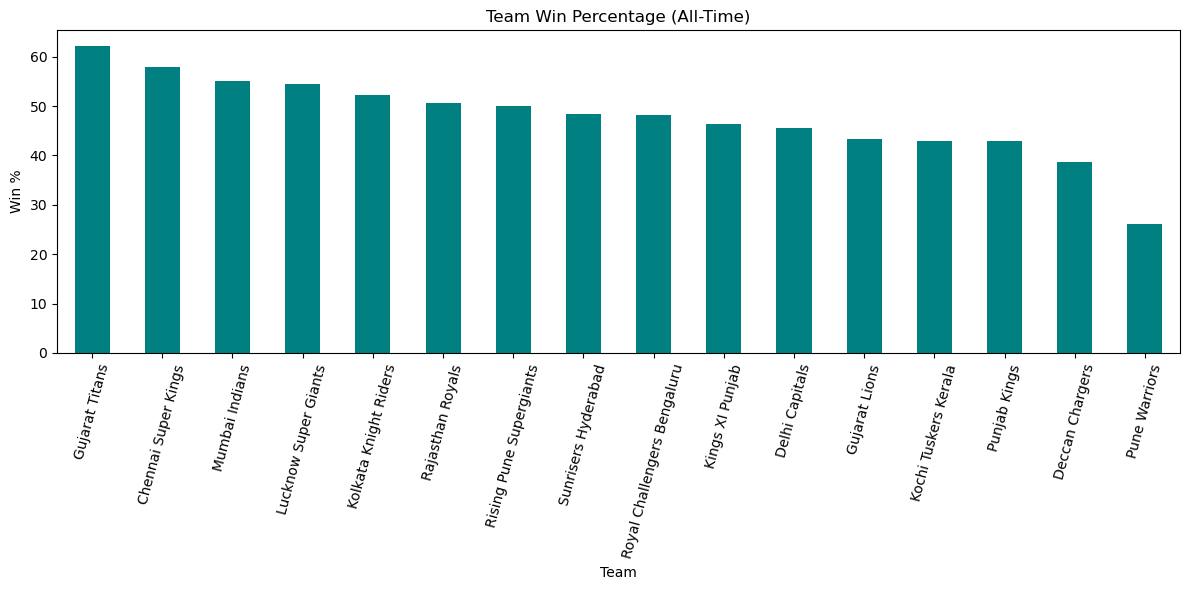

In [33]:
# 6.3 Team win % bar chart
plt.figure(figsize=(12,6))
win_pct.plot(kind="bar", color="teal")
plt.title("Team Win Percentage (All-Time)")
plt.xlabel("Team")
plt.ylabel("Win %")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


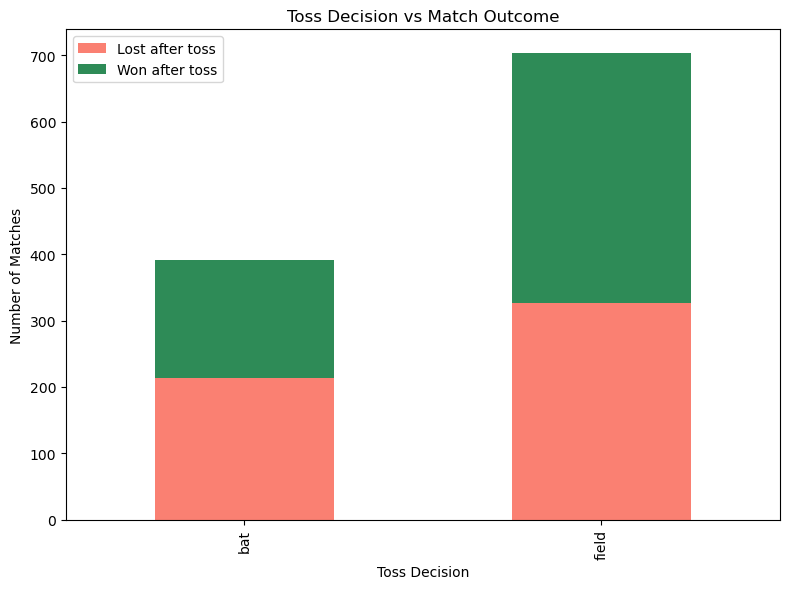

In [34]:
# 6.4 Toss decision vs match outcome — stacked bar
toss_outcome = matches.groupby(["toss_decision", "toss_win_match_win"]).size().unstack()

toss_outcome.plot(kind="bar", stacked=True, figsize=(8,6), color=["salmon", "seagreen"])
plt.title("Toss Decision vs Match Outcome")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")
plt.legend(["Lost after toss", "Won after toss"])
plt.tight_layout()
plt.show()
